# Phase 07 : Transfer Learning + Amplitude Scaling

In [2]:
"""
Now we are combining:

BEST + BEST models :
 -> Best overall method : Transfer Learning
 -> Best augmentation : Amplitude Scaling
This is exactly research novelty is built.

we are doing now is, combining both.
Earlier:
Transfer Learning -> 15.66%
Amplitude Scaling -> 15.09%
Now:
Combine both and test: Transfer Learning + Amplitude Scaling

Actual goal is :
“Can we improve performance further by combining cross-subject learning with better data variation?”

To do that, firstly,
We will ONLY change one thing:
During fine-tuning -> apply amplitude scaling to training data

We will NOT:
  - change pretraining
  - change folds
  - change model
This keeps experiment fair.



"""

'\nNow we are combining:\n\nBEST + BEST models :\n -> Best overall method : Transfer Learning\n -> Best augmentation : Amplitude Scaling\nThis is exactly research novelty is built.\n\nwe are doing now is, combining both.\nEarlier:\nTransfer Learning -> 15.66%\nAmplitude Scaling -> 15.09%\nNow:\nCombine both and test: Transfer Learning + Amplitude Scaling\n\nActual goal is :\n“Can we improve performance further by combining cross-subject learning with better data variation?”\n\nTo do that, firstly,\nWe will ONLY change one thing:\nDuring fine-tuning -> apply amplitude scaling to training data\n\nWe will NOT:\n  - change pretraining\n  - change folds\n  - change model\nThis keeps experiment fair.\n\n\n\n'

In [3]:
# ---------------------------------------
# step 1 : Mount Google Drive
# ---------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ---------------------------------------
# step 2: importing the required libraries
# ---------------------------------------

import os
import random
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D
from tensorflow.keras.layers import AveragePooling2D, SeparableConv2D
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical

In [5]:
# ---------------------------------------
# step 3 : Basic experiment settings
# ---------------------------------------


random_seed = 42
subject_file_name = "S14_EEG.mat"

dataset_folder = "/content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14"
results_folder = "/content/drive/MyDrive/Colab_Notebooks/My_Project/Results_April2026"

number_of_signal_columns = 24576
number_of_channels = 6
number_of_samples_per_trial = 4096
number_of_folds = 5

batch_size = 16
number_of_epochs = 50
validation_size_inside_training = 0.2

In [6]:
# ---------------------------------------
# step 4 : make results folder and fix randomness
# ---------------------------------------

# Creates the results folder if it doesn't exist
os.makedirs(results_folder, exist_ok=True)

np.random.seed(random_seed)
random.seed(random_seed)
tf.random.set_seed(random_seed)
print("==============================================")
print("Results folder is ready.")
print("Random seed is set.")
print("==============================================")

Results folder is ready.
Random seed is set.


In [7]:
# ---------------------------------------
# step 5 : building the subject path and load the file
# ---------------------------------------

import scipy.io as sio

subject_file_name = "S14_EEG.mat"

subject_file_path = os.path.join(dataset_folder, subject_file_name)

print("==============================================")
print("Subject file path:", subject_file_path)
print("Does file exist?", os.path.exists(subject_file_path))
print("==============================================")
mat_data = sio.loadmat(subject_file_path)
print("==============================================")
print("\nThe .mat file loaded successfully.")
print("Available keys inside the file:", mat_data.keys())
print("==============================================")

Subject file path: /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14/S14_EEG.mat
Does file exist? True

The .mat file loaded successfully.
Available keys inside the file: dict_keys(['__header__', '__version__', '__globals__', 'EEG'])


In [8]:
# ---------------------------------------
# step 6 : extract EEG matrix and printing shape
# ---------------------------------------

eeg_matrix = mat_data["EEG"]
print("==============================================")
print("EEG matrix extracted.")
print("number_of_trials, number_of_columns are : ")
print("==============================================")
print("EEG matrix shape:", eeg_matrix.shape)
print("==============================================")

EEG matrix extracted.
number_of_trials, number_of_columns are : 
EEG matrix shape: (639, 24579)


In [9]:
# ---------------------------------------
# step 7 : separating the signal data and metadata columns
# ---------------------------------------

number_of_signal_columns = 24576

signal_data = eeg_matrix[:, :number_of_signal_columns]
modality_column = eeg_matrix[:, number_of_signal_columns]
stimulus_column = eeg_matrix[:, number_of_signal_columns + 1]
artifact_column = eeg_matrix[:, number_of_signal_columns + 2]

print("==============================================")
print("Signal data shape:", signal_data.shape)
print("Modality column shape:", modality_column.shape)
print("Stimulus column shape:", stimulus_column.shape)
print("Artifact column shape:", artifact_column.shape)
print("==============================================")

print("Unique modality values:", np.unique(modality_column))
print("Unique stimulus values:", np.unique(stimulus_column))
print("Unique artifact values:", np.unique(artifact_column))
print("==============================================")


Signal data shape: (639, 24576)
Modality column shape: (639,)
Stimulus column shape: (639,)
Artifact column shape: (639,)
Unique modality values: [1. 2.]
Unique stimulus values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Unique artifact values: [1. 2.]


In [10]:
# ---------------------------------------
# step 8: filtering only imagined speech and valid trials
# ---------------------------------------

valid_trial_mask = (modality_column == 1) & (artifact_column == 1)

filtered_signal_data = signal_data[valid_trial_mask]
filtered_labels = stimulus_column[valid_trial_mask]

print("==============================================")
print("Number of valid filtered trials:", len(filtered_labels))
print("Filtered signal shape:", filtered_signal_data.shape)
print("Filtered labels shape:", filtered_labels.shape)
print("==============================================")

print("Unique filtered labels:", np.unique(filtered_labels))
print("==============================================")

Number of valid filtered trials: 351
Filtered signal shape: (351, 24576)
Filtered labels shape: (351,)
Unique filtered labels: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


In [11]:
# ---------------------------------------
# step 9: reshape filtered signal into trial format
# ---------------------------------------


number_of_channels = 6
number_of_samples_per_trial = 4096

X = filtered_signal_data.reshape(-1, number_of_channels, number_of_samples_per_trial)
y = filtered_labels.astype(int)

print("==============================================")
print("X shape after reshape:", X.shape)
print("y shape:", y.shape)
print("==============================================")

X shape after reshape: (351, 6, 4096)
y shape: (351,)


In [12]:
# ---------------------------------------
# step 10 : prepare labels for classification - shift labels to 0 ... 10
# ---------------------------------------

y = y - 1

number_of_classes = len(np.unique(y))
label_counts = pd.Series(y).value_counts().sort_index()

print("==============================================")
print("Unique labels after shifting to 0-based indexing:")
print(np.unique(y))
print("==============================================")

print("Number of classes:", number_of_classes)
print("==============================================")

print("Class counts:")
print(label_counts)
print("==============================================")

Unique labels after shifting to 0-based indexing:
[ 0  1  2  3  4  5  6  7  8  9 10]
Number of classes: 11
Class counts:
0     35
1     40
2     37
3     33
4     34
5     28
6     32
7     31
8     27
9     25
10    29
Name: count, dtype: int64


In [13]:
# TL Step 1 — Define a reusable subject loading + preprocessing function


# ==============================================
# Transfer Learning - Step 1:
# reusable function to load and preprocess one subject
# ==============================================

def load_and_preprocess_subject(subject_file_path):
    # ------------------------------------------
    # Step 1.1: load the .mat file
    # ------------------------------------------
    mat_data = sio.loadmat(subject_file_path)

    # ------------------------------------------
    # Step 1.2: extract EEG matrix
    # ------------------------------------------
    eeg_matrix = mat_data["EEG"]

    # ------------------------------------------
    # Step 1.3: separate signal and metadata
    # ------------------------------------------
    signal_data = eeg_matrix[:, :number_of_signal_columns]
    modality_column = eeg_matrix[:, number_of_signal_columns]
    stimulus_column = eeg_matrix[:, number_of_signal_columns + 1]
    artifact_column = eeg_matrix[:, number_of_signal_columns + 2]

    # ------------------------------------------
    # Step 1.4: keep imagined speech + valid trials only
    # ------------------------------------------
    valid_trial_mask = (modality_column == 1) & (artifact_column == 1)

    filtered_signal_data = signal_data[valid_trial_mask]
    filtered_labels = stimulus_column[valid_trial_mask]

    # ------------------------------------------
    # Step 1.5: reshape into (trials, channels, samples)
    # ------------------------------------------
    X_subject = filtered_signal_data.reshape(
        -1,
        number_of_channels,
        number_of_samples_per_trial
    )

    # ------------------------------------------
    # Step 1.6: convert labels to integers and shift to 0-based
    # ------------------------------------------
    y_subject = filtered_labels.astype(int)
    y_subject = y_subject - 1

    return X_subject, y_subject

In [14]:
# TL Step 2 — Test this function on S14 only

# ==============================================
# Transfer Learning - Step 2:
# test the reusable function on target subject S14
# ==============================================

target_subject_file_path = "/content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14/S14_EEG.mat"

X_target, y_target = load_and_preprocess_subject(target_subject_file_path)

print("==============================================")
print("Target subject loaded successfully.")
print("X_target shape:", X_target.shape)
print("y_target shape:", y_target.shape)
print("Unique labels:", np.unique(y_target))
print("==============================================")

Target subject loaded successfully.
X_target shape: (351, 6, 4096)
y_target shape: (351,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]


In [15]:
# TL — Step 3: Build subject file paths


# ==============================================
# Transfer Learning - Step 3:
# create subject file paths
# ==============================================

base_dataset_folder = "/content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada"

subject_names = [
    "S01", "S02", "S03", "S04", "S05", "S06", "S07",
    "S08", "S09", "S10", "S11", "S12", "S13", "S14", "S15"
]

subject_file_paths = {}

for subject_name in subject_names:
    subject_file_name = subject_name + "_EEG.mat"
    subject_file_path = os.path.join(base_dataset_folder, subject_name, subject_file_name)
    subject_file_paths[subject_name] = subject_file_path

print("==============================================")
print("Total subjects listed:", len(subject_file_paths))
print("==============================================")

for subject_name, subject_file_path in subject_file_paths.items():
    print(subject_name, "->", subject_file_path)

Total subjects listed: 15
S01 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S01/S01_EEG.mat
S02 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S02/S02_EEG.mat
S03 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S03/S03_EEG.mat
S04 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S04/S04_EEG.mat
S05 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S05/S05_EEG.mat
S06 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S06/S06_EEG.mat
S07 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S07/S07_EEG.mat
S08 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S08/S08_EEG.mat
S09 -> /content/drive/

In [16]:
# TL Step 4 — Check which files actually exist


# ==============================================
# Transfer Learning - Step 4:
# check which subject files actually exist
# ==============================================

existing_subject_file_paths = {}
missing_subjects = []

for subject_name, subject_file_path in subject_file_paths.items():
    if os.path.exists(subject_file_path):
        existing_subject_file_paths[subject_name] = subject_file_path
    else:
        missing_subjects.append(subject_name)

print("==============================================")
print("Existing subject files:", len(existing_subject_file_paths))
print("Missing subjects:", missing_subjects)
print("==============================================")

for subject_name, subject_file_path in existing_subject_file_paths.items():
    print(subject_name, "exists")

Existing subject files: 15
Missing subjects: []
S01 exists
S02 exists
S03 exists
S04 exists
S05 exists
S06 exists
S07 exists
S08 exists
S09 exists
S10 exists
S11 exists
S12 exists
S13 exists
S14 exists
S15 exists


In [17]:
# TL — Step 5: Separate target and non-target subjects


# ==============================================
# Transfer Learning - Step 5:
# choose target subject and pretraining subjects
# ==============================================

target_subject_name = "S14"

target_subject_path = existing_subject_file_paths[target_subject_name]

pretraining_subject_paths = {}

for subject_name, subject_file_path in existing_subject_file_paths.items():
    if subject_name != target_subject_name:
        pretraining_subject_paths[subject_name] = subject_file_path

print("==============================================")
print("Target subject:", target_subject_name)
print("Target subject path:", target_subject_path)
print("Number of pretraining subjects:", len(pretraining_subject_paths))
print("==============================================")

for subject_name in pretraining_subject_paths:
    print(subject_name, "will be used for pretraining")

Target subject: S14
Target subject path: /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14/S14_EEG.mat
Number of pretraining subjects: 14
S01 will be used for pretraining
S02 will be used for pretraining
S03 will be used for pretraining
S04 will be used for pretraining
S05 will be used for pretraining
S06 will be used for pretraining
S07 will be used for pretraining
S08 will be used for pretraining
S09 will be used for pretraining
S10 will be used for pretraining
S11 will be used for pretraining
S12 will be used for pretraining
S13 will be used for pretraining
S15 will be used for pretraining


In [18]:
# TL — Step 6: Load the target subject and create its 5 folds

# ==============================================
# Transfer Learning - Step 6:
# load target subject and create 5 folds
# ==============================================

X_target, y_target = load_and_preprocess_subject(target_subject_path)

print("==============================================")
print("Target subject loaded for transfer learning.")
print("X_target shape:", X_target.shape)
print("y_target shape:", y_target.shape)
print("Unique labels:", np.unique(y_target))
print("==============================================")

target_stratified_kfold = StratifiedKFold(
    n_splits=number_of_folds,
    shuffle=True,
    random_state=random_seed
)

target_fold_splits = list(target_stratified_kfold.split(X_target, y_target))

print("Number of target folds:", len(target_fold_splits))
print("==============================================")

for fold_number, (train_indices, test_indices) in enumerate(target_fold_splits, start=1):
    print("Fold", fold_number)
    print("Train size:", len(train_indices))
    print("Test size:", len(test_indices))
    print("----------------------------------------------")

Target subject loaded for transfer learning.
X_target shape: (351, 6, 4096)
y_target shape: (351,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Number of target folds: 5
Fold 1
Train size: 280
Test size: 71
----------------------------------------------
Fold 2
Train size: 281
Test size: 70
----------------------------------------------
Fold 3
Train size: 281
Test size: 70
----------------------------------------------
Fold 4
Train size: 281
Test size: 70
----------------------------------------------
Fold 5
Train size: 281
Test size: 70
----------------------------------------------


In [19]:
# TL — Step 7: Build the combined pretraining dataset


# ==============================================
# Transfer Learning - Step 7:
# build combined pretraining dataset
# ==============================================

X_pretraining_list = []
y_pretraining_list = []

for subject_name, subject_file_path in pretraining_subject_paths.items():
    X_subject, y_subject = load_and_preprocess_subject(subject_file_path)

    X_pretraining_list.append(X_subject)
    y_pretraining_list.append(y_subject)

    print("Loaded", subject_name)
    print("  X shape:", X_subject.shape)
    print("  y shape:", y_subject.shape)
    print("  Number of trials:", len(y_subject))
    print("----------------------------------------------")

X_pretraining = np.concatenate(X_pretraining_list, axis=0)
y_pretraining = np.concatenate(y_pretraining_list, axis=0)

print("==============================================")
print("Combined pretraining dataset ready.")
print("X_pretraining shape:", X_pretraining.shape)
print("y_pretraining shape:", y_pretraining.shape)
print("Unique labels:", np.unique(y_pretraining))
print("==============================================")

Loaded S01
  X shape: (278, 6, 4096)
  y shape: (278,)
  Number of trials: 278
----------------------------------------------
Loaded S02
  X shape: (424, 6, 4096)
  y shape: (424,)
  Number of trials: 424
----------------------------------------------
Loaded S03
  X shape: (357, 6, 4096)
  y shape: (357,)
  Number of trials: 357
----------------------------------------------
Loaded S04
  X shape: (421, 6, 4096)
  y shape: (421,)
  Number of trials: 421
----------------------------------------------
Loaded S05
  X shape: (303, 6, 4096)
  y shape: (303,)
  Number of trials: 303
----------------------------------------------
Loaded S06
  X shape: (221, 6, 4096)
  y shape: (221,)
  Number of trials: 221
----------------------------------------------
Loaded S07
  X shape: (406, 6, 4096)
  y shape: (406,)
  Number of trials: 406
----------------------------------------------
Loaded S08
  X shape: (409, 6, 4096)
  y shape: (409,)
  Number of trials: 409
---------------------------------------

In [20]:
# TL — Step 8: Prepare the pretraining dataset

# ==============================================
# Transfer Learning - Step 8:
# normalize and prepare pretraining dataset
# ==============================================

pretraining_mean = np.mean(X_pretraining)
pretraining_std = np.std(X_pretraining)

if pretraining_std == 0:
    pretraining_std = 1.0

X_pretraining_normalized = (X_pretraining - pretraining_mean) / pretraining_std

X_pretraining_normalized = X_pretraining_normalized[..., np.newaxis]

y_pretraining_one_hot = to_categorical(
    y_pretraining,
    num_classes=number_of_classes
)

print("==============================================")
print("Pretraining data prepared successfully.")
print("X_pretraining_normalized shape:", X_pretraining_normalized.shape)
print("y_pretraining_one_hot shape:", y_pretraining_one_hot.shape)
print("==============================================")

Pretraining data prepared successfully.
X_pretraining_normalized shape: (5098, 6, 4096, 1)
y_pretraining_one_hot shape: (5098, 11)


In [21]:
# TL Step 9 - Make sure the baseline EEGNet model id defined


# ==============================================
# Transfer Learning - Step 9:
# baseline EEGNet model
# ==============================================

def build_baseline_eegnet(input_shape, number_of_classes):
    input_layer = Input(shape=input_shape)

    block_1 = Conv2D(
        filters=8,
        kernel_size=(1, 64),
        padding="same",
        use_bias=False
    )(input_layer)
    block_1 = BatchNormalization()(block_1)

    block_1 = DepthwiseConv2D(
        kernel_size=(input_shape[0], 1),
        depth_multiplier=2,
        use_bias=False,
        depthwise_constraint=max_norm(1.0)
    )(block_1)
    block_1 = BatchNormalization()(block_1)
    block_1 = Activation("elu")(block_1)
    block_1 = AveragePooling2D(pool_size=(1, 4))(block_1)
    block_1 = Dropout(0.5)(block_1)

    block_2 = SeparableConv2D(
        filters=16,
        kernel_size=(1, 16),
        padding="same",
        use_bias=False
    )(block_1)
    block_2 = BatchNormalization()(block_2)
    block_2 = Activation("elu")(block_2)
    block_2 = AveragePooling2D(pool_size=(1, 8))(block_2)
    block_2 = Dropout(0.5)(block_2)

    flatten_layer = Flatten()(block_2)

    output_layer = Dense(
        units=number_of_classes,
        activation="softmax",
        kernel_constraint=max_norm(0.25)
    )(flatten_layer)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [22]:
# TL Step 10 — Do the first pretraining run


# ==============================================
# Transfer Learning - Step 10:
# pretrain baseline EEGNet on non-target subjects
# ==============================================

pretraining_input_shape = (number_of_channels, number_of_samples_per_trial, 1)

pretrained_model = build_baseline_eegnet(
    input_shape=pretraining_input_shape,
    number_of_classes=number_of_classes
)

print("==============================================")
print("Starting pretraining on non-target subjects...")
print("X_pretraining_normalized shape:", X_pretraining_normalized.shape)
print("y_pretraining_one_hot shape:", y_pretraining_one_hot.shape)
print("==============================================")

pretraining_history = pretrained_model.fit(
    X_pretraining_normalized,
    y_pretraining_one_hot,
    epochs=20,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1)

Starting pretraining on non-target subjects...
X_pretraining_normalized shape: (5098, 6, 4096, 1)
y_pretraining_one_hot shape: (5098, 11)
Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 128s 491ms/step - accuracy: 0.1199 - loss: 2.3819 - val_accuracy: 0.1265 - val_loss: 2.3440
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 118s 465ms/step - accuracy: 0.1317 - loss: 2.3366 - val_accuracy: 0.1353 - val_loss: 2.3198
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 125s 399ms/step - accuracy: 0.1282 - loss: 2.3273 - val_accuracy: 0.1363 - val_loss: 2.3168
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 144s 406ms/step - accuracy: 0.1385 - loss: 2.3175 - val_accuracy: 0.1333 - val_loss: 2.3178
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.1297 - loss: 2.3143 - val_accuracy: 0.1480 - val_loss: 2.3163
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 145s 408ms/step - accuracy: 0.1307 - loss: 2.3146 - val_accuracy: 0.1402 - val_loss: 2.3136
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 102s 401ms/step - accuracy: 0.

In [23]:
# TL Step 11A — Create a helper function to copy pretrained weights into a new model


# ==============================================
# Transfer Learning - Step 11A:
# create a fresh model and copy pretrained weights
# ==============================================

def create_finetuning_model_from_pretrained(pretrained_model, input_shape, number_of_classes):
    finetuning_model = build_baseline_eegnet(
        input_shape=input_shape,
        number_of_classes=number_of_classes
    )

    finetuning_model.set_weights(pretrained_model.get_weights())

    finetuning_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return finetuning_model

In [24]:

# DEfining Amplitute Scaling

# ==============================================
# define amplitude scaling function again
# ==============================================

def apply_amplitude_scaling(data_array, min_scale=0.9, max_scale=1.1):
    scaling_factors = np.random.uniform(
        low=min_scale,
        high=max_scale,
        size=(data_array.shape[0], 1, 1)
    )

    scaled_data = data_array * scaling_factors
    return scaled_data

In [25]:
# STEP 1 — Create new function (Transfer + Amplitude Scaling)

# ==============================================
# Transfer Learning + Amplitude Scaling
# ==============================================

def run_one_transfer_learning_with_amplitude(
    X_target,
    y_target,
    train_indices,
    test_indices,
    fold_number,
    pretrained_model,
    min_scale=0.9,
    max_scale=1.1
):
    # Step 1: split data
    X_train_full = X_target[train_indices]
    y_train_full = y_target[train_indices]

    X_test = X_target[test_indices]
    y_test = y_target[test_indices]

    # Step 2: validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=validation_size_inside_training,
        stratify=y_train_full,
        random_state=random_seed
    )

    # NEW PART — amplitude scaling
    X_train_augmented = apply_amplitude_scaling(
        X_train,
        min_scale=min_scale,
        max_scale=max_scale
    )
    y_train_augmented = y_train.copy()

    # combine original + augmented
    X_train_combined = np.concatenate([X_train, X_train_augmented], axis=0)
    y_train_combined = np.concatenate([y_train, y_train_augmented], axis=0)

    # normalization
    mean = np.mean(X_train_combined)
    std = np.std(X_train_combined)
    if std == 0:
        std = 1.0

    X_train_combined = (X_train_combined - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std

    # reshape
    X_train_combined = X_train_combined[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    # one-hot
    y_train_combined = to_categorical(y_train_combined, num_classes=number_of_classes)
    y_val = to_categorical(y_val, num_classes=number_of_classes)
    y_test = to_categorical(y_test, num_classes=number_of_classes)

    # load pretrained weights
    input_shape = (number_of_channels, number_of_samples_per_trial, 1)

    model = create_finetuning_model_from_pretrained(
        pretrained_model,
        input_shape,
        number_of_classes
    )

    print("==============================================")
    print("Transfer + Amplitude Scaling Fold:", fold_number)
    print("Train shape:", X_train_combined.shape)
    print("Validation shape:", X_val.shape)
    print("Test shape:", X_test.shape)
    print("==============================================")

    # train
    history = model.fit(
        X_train_combined,
        y_train_combined,
        epochs=20,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=1
    )

    # evaluate
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Fold", fold_number, "accuracy:", test_accuracy)

    return {
        "fold_number": fold_number,
        "test_accuracy": test_accuracy
    }, history


In [26]:
# TL + AS STEP 2 — Run Fold 1 first


first_train_indices, first_test_indices = target_fold_splits[0]

result, history = run_one_transfer_learning_with_amplitude(
    X_target,
    y_target,
    first_train_indices,
    first_test_indices,
    fold_number=1,
    pretrained_model=pretrained_model
)

print(result)

Transfer + Amplitude Scaling Fold: 1
Train shape: (448, 6, 4096, 1)
Validation shape: (56, 6, 4096, 1)
Test shape: (71, 6, 4096, 1)
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 582ms/step - accuracy: 0.2500 - loss: 2.0785 - val_accuracy: 0.0536 - val_loss: 2.2175
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 410ms/step - accuracy: 0.6205 - loss: 1.6667 - val_accuracy: 0.0357 - val_loss: 2.2280
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 420ms/step - accuracy: 0.7768 - loss: 1.4639 - val_accuracy: 0.0893 - val_loss: 2.2389
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - accuracy: 0.8170 - loss: 1.3641 - val_accuracy: 0.1071 - val_loss: 2.2478
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 417ms/step - accuracy: 0.8504 - loss: 1.2992 - val_accuracy: 0.1250 - val_loss: 2.2506
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.8683 - loss: 1.2629 - val_accuracy: 0.1429 - val_loss: 2.2459
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 425ms/step - accuracy: 0.9040 - loss: 1.2169 - val_a

In [27]:
"""
Fold 1 accuracy: 0.1690
Fold 1 Outcome :

After applying both transfer learning and amplitude scaling together,
 the accuracy for Fold 1 comes out to:
0.1690, which is roughly 16.90%
How this compares to earlier results

If we look back at the previous result for the same fold:

Transfer learning alone had reached about 19.72%
Now,
 after adding amplitude scaling during fine-tuning,
  it has dropped to 16.90%

So,
 for this specific fold,
  combining the two methods has actually led to a lower performance than using transfer learning by itself.

What we can understand from this

It’s important not to jump to conclusions too quickly,
 since this is only one fold out of several.
  Still, there are a couple of useful takeaways:

First,
 the combined setup is running as expected,
  so technically everything is working fine.
Second,
 simply adding amplitude scaling during fine-tuning
  does not guarantee better results.
   Sometimes, even strong methods don’t improve things when combined.

This kind of outcome is quite common in research,
 especially when experimenting with combinations.

Another thing to notice is that the validation performance is still relatively low,
 which suggests the model may still be overfitting and not generalizing well.

What to do next :

At this point,
 it would be too early to judge the effectiveness of this
  combined approach based on just one fold.

The right next step is straightforward:

    * Run the experiment across all 5 folds
    * Then evaluate the overall trend before making any final decision



"""

'\nFold 1 accuracy: 0.1690\nFold 1 Outcome : \n\nAfter applying both transfer learning and amplitude scaling together,\n the accuracy for Fold 1 comes out to: \n0.1690, which is roughly 16.90%\nHow this compares to earlier results\n\nIf we look back at the previous result for the same fold:\n\nTransfer learning alone had reached about 19.72%\nNow,\n after adding amplitude scaling during fine-tuning,\n  it has dropped to 16.90%\n\nSo,\n for this specific fold,\n  combining the two methods has actually led to a lower performance than using transfer learning by itself.\n\nWhat we can understand from this\n\nIt’s important not to jump to conclusions too quickly,\n since this is only one fold out of several.\n  Still, there are a couple of useful takeaways:\n\nFirst,\n the combined setup is running as expected,\n  so technically everything is working fine.\nSecond,\n simply adding amplitude scaling during fine-tuning\n  does not guarantee better results.\n   Sometimes, even strong methods d

In [28]:
# Run all 5 folds


# ==============================================
# Transfer Learning + Amplitude Scaling
# Run all 5 folds
# ==============================================

all_transfer_amplitude_results = []
all_transfer_amplitude_histories = []

for fold_number, (train_indices, test_indices) in enumerate(target_fold_splits, start=1):
    fold_result, fold_history = run_one_transfer_learning_with_amplitude(
        X_target,
        y_target,
        train_indices,
        test_indices,
        fold_number=fold_number,
        pretrained_model=pretrained_model
    )

    all_transfer_amplitude_results.append(fold_result)
    all_transfer_amplitude_histories.append(fold_history)

print("==============================================")
print("All 5 Transfer + Amplitude Scaling folds finished.")
print("==============================================")

Transfer + Amplitude Scaling Fold: 1
Train shape: (448, 6, 4096, 1)
Validation shape: (56, 6, 4096, 1)
Test shape: (71, 6, 4096, 1)
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 393ms/step - accuracy: 0.2500 - loss: 2.0938 - val_accuracy: 0.0714 - val_loss: 2.2068
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - accuracy: 0.6496 - loss: 1.6724 - val_accuracy: 0.0179 - val_loss: 2.2123
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step - accuracy: 0.7478 - loss: 1.4886 - val_accuracy: 0.0893 - val_loss: 2.2395
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - accuracy: 0.8103 - loss: 1.3791 - val_accuracy: 0.0893 - val_loss: 2.2447
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 421ms/step - accuracy: 0.8638 - loss: 1.3060 - val_accuracy: 0.1429 - val_loss: 2.2525
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 418ms/step - accuracy: 0.8839 - loss: 1.2548 - val_accuracy: 0.1429 - val_loss: 2.2588
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - accuracy: 0.8951 - loss: 1.2206 - val_a

In [29]:
transfer_amplitude_results_dataframe = pd.DataFrame(all_transfer_amplitude_results)

print(transfer_amplitude_results_dataframe)

   fold_number  test_accuracy
0            1       0.154930
1            2       0.157143
2            3       0.142857
3            4       0.142857
4            5       0.171429


In [30]:
transfer_amplitude_mean_accuracy = transfer_amplitude_results_dataframe["test_accuracy"].mean()
transfer_amplitude_std_accuracy = transfer_amplitude_results_dataframe["test_accuracy"].std()

print("Fold accuracies:", transfer_amplitude_results_dataframe["test_accuracy"].tolist())
print("Mean accuracy:", transfer_amplitude_mean_accuracy)
print("Standard deviation:", transfer_amplitude_std_accuracy)
print("Mean ± Std:", str(round(transfer_amplitude_mean_accuracy, 4)) + " ± " + str(round(transfer_amplitude_std_accuracy, 4)))

Fold accuracies: [0.15492957830429077, 0.15714286267757416, 0.1428571492433548, 0.1428571492433548, 0.17142857611179352]
Mean accuracy: 0.1538430631160736
Standard deviation: 0.01186064992907778
Mean ± Std: 0.1538 ± 0.0119


In [31]:
"""

## Final Results Summary :

When transfer learning was combined with amplitude scaling,
 the model produced the following results across the folds:

      * Fold accuracies: 15.49%, 15.71%, 14.29%, 14.29%, 17.14%
      * Average accuracy: 15.38%
      * Standard deviation: 1.19%
        So overall,
         this method achieved 15.38% ± 1.19%.

## Comparison Across All Methods

Looking at all the approaches side by side:

1. Baseline EEGNet → 12.82% ± 2.67%
2. EEGNet with Attention → 12.53% ± 3.68%
3. EEGNet with Gaussian Noise → 14.80% ± 4.06%
4. EEGNet with Amplitude Scaling → 15.09% ± 4.16%
5. EEGNet with Time Shifting → 14.25% ± 4.06%
6. Transfer Learning with EEGNet → 15.66% ± 2.93%
7. Transfer Learning with Amplitude Scaling → 15.38% ± 1.19%

## What These Results Actually Show

### 1. Best Average Performance
The highest average accuracy comes from:
      * Transfer Learning + EEGNet (15.66%)
This means,
 on average,
  this approach gives the best predictions.

### 2. Most Consistent Method
The method with the smallest variation between folds is:
    * Transfer Learning + Amplitude Scaling (±1.19%)
This tells us that its performance is very steady and does not fluctuate much across different data splits.

## Key Insights are :

This is where the result becomes meaningful:
      * Using transfer learning alone gives the best overall accuracy.
      * Adding amplitude scaling on top of it does not increase the average score
      * However, it significantly reduces how much the results vary** from one fold to another.

In other terms, we can say:
      * We don’t gain higher accuracy,
      * but we get a model that behaves more reliably and consistently.
That’s not a negative outcome — it’s actually a useful and valid finding.

## We can explain this like :

we could describe it like this:

      * Combining transfer learning with amplitude scaling
         did not outperform transfer learning alone in terms of average accuracy.
      * However,
         it resulted in the lowest variation across folds,
          showing that the model became more stable and dependable.

## Ranking the Methods (Based on Average Accuracy)

From highest to lowest:

1. Transfer Learning + EEGNet → 15.66%
2. Transfer Learning + Amplitude Scaling → 15.38%
3. EEGNet + Amplitude Scaling → 15.09%
4. EEGNet + Gaussian Noise → 14.80%
5. EEGNet + Time Shifting → 14.25%
6. Baseline EEGNet → 12.82%
7. EEGNet + Attention → 12.53%

## Final Takeaway for the Thesis :

We can summarize the overall findings like this:

      *** The basic model performs poorly.
      *** Adding attention does not improve results.
      *** Data augmentation techniques help a bit.
      *** Transfer learning gives the biggest improvement.
      *** Adding amplitude scaling to transfer learning makes the model more stable,
       even if it does not boost accuracy further.

The model works best when you use transfer learning.
When amplitude scaling is added,
 the accuracy drops slightly,
  but the results become much more consistent across different tests.
So,
 even though it’s not the top performer,
  it’s more reliable.

"""


'\n\n## Final Results Summary : \n\nWhen transfer learning was combined with amplitude scaling,\n the model produced the following results across the folds:\n\n      * Fold accuracies: 15.49%, 15.71%, 14.29%, 14.29%, 17.14%\n      * Average accuracy: 15.38%\n      * Standard deviation: 1.19%\n        So overall,\n         this method achieved 15.38% ± 1.19%.\n\n## Comparison Across All Methods\n\nLooking at all the approaches side by side:\n\n1. Baseline EEGNet → 12.82% ± 2.67%\n2. EEGNet with Attention → 12.53% ± 3.68%\n3. EEGNet with Gaussian Noise → 14.80% ± 4.06%\n4. EEGNet with Amplitude Scaling → 15.09% ± 4.16%\n5. EEGNet with Time Shifting → 14.25% ± 4.06%\n6. Transfer Learning with EEGNet → 15.66% ± 2.93%\n7. Transfer Learning with Amplitude Scaling → 15.38% ± 1.19%\n\n## What These Results Actually Show\n\n### 1. Best Average Performance\nThe highest average accuracy comes from:\n      * Transfer Learning + EEGNet (15.66%)\nThis means,\n on average,\n  this approach gives the 

# Visualization of phase 07

In [34]:
# Fold accuracies = [0.1549, 0.1571, 0.1429, 0.1429, 0.1714]

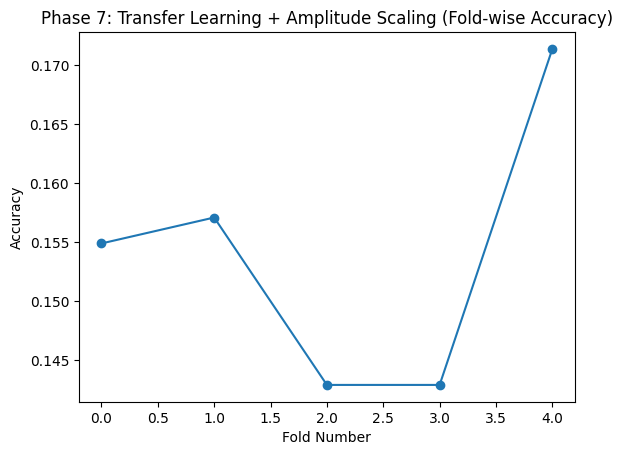

In [35]:
# Fold-wise accuracy plot

import matplotlib.pyplot as plt

phase7_fold_accuracies = [0.1549, 0.1571, 0.1429, 0.1429, 0.1714]

plt.figure()

plt.plot(phase7_fold_accuracies, marker='o')

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Phase 7: Transfer Learning + Amplitude Scaling (Fold-wise Accuracy)")

plt.show()


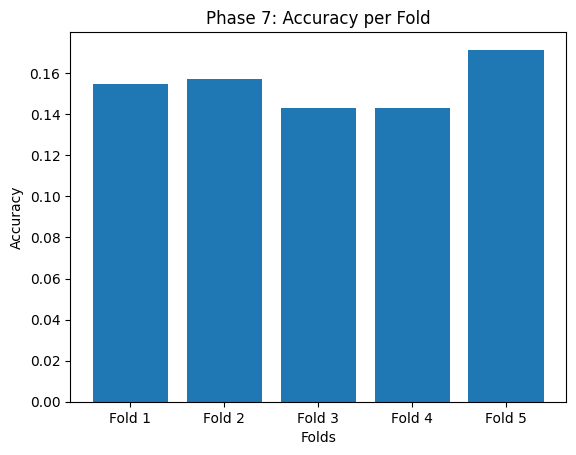

In [36]:
# Bar plot

plt.figure()

plt.bar(["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"], phase7_fold_accuracies)

plt.xlabel("Folds")
plt.ylabel("Accuracy")
plt.title("Phase 7: Accuracy per Fold")

plt.show()

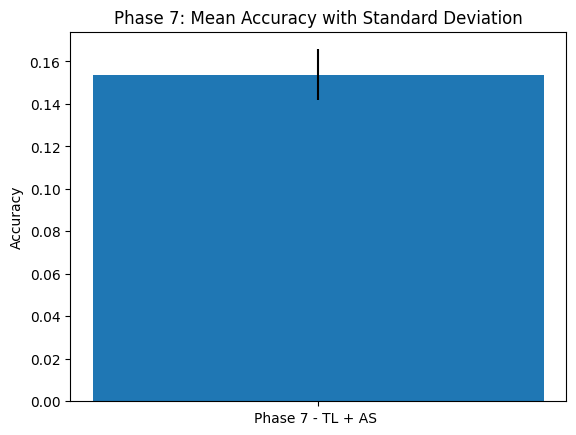

In [38]:
# Mean ± Std visualization


mean_accuracy = 0.1538
std_dev = 0.0119

plt.figure()

plt.bar(["Phase 7 - TL + AS "], [mean_accuracy], yerr=[std_dev])

plt.ylabel("Accuracy")
plt.title("Phase 7: Mean Accuracy with Standard Deviation")

plt.show()



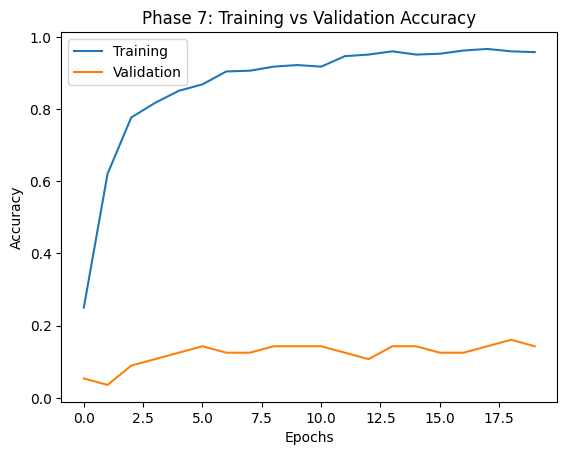

In [39]:
# Training vs Validation curve (IMPORTANT)

history = history  #  Phase 7 history

plt.figure()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Phase 7: Training vs Validation Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

# Phase 7 (Transfer Learning + Amplitude Scaling) to comparison with other phases

In [40]:
# STEP 1 — Update your results table (including Phase 7)


# ==============================================
# Final Comparison including Phase 7
# ==============================================

results_summary = pd.DataFrame({
    "Method": [
        "Baseline EEGNet",
        "EEGNet + Attention",
        "EEGNet + Gaussian Noise",
        "EEGNet + Amplitude Scaling",
        "EEGNet + Time Shifting",
        "Transfer Learning + EEGNet",
        "Transfer Learning + Amplitude Scaling"
    ],
    "Mean Accuracy": [
        0.1282,
        0.1253,
        0.1480,
        0.1509,
        0.1425,
        0.1566,
        0.1538
    ],
    "Std Dev": [
        0.0267,
        0.0368,
        0.0406,
        0.0416,
        0.0406,
        0.0293,
        0.0119
    ]
})

print(results_summary)

                                  Method  Mean Accuracy  Std Dev
0                        Baseline EEGNet         0.1282   0.0267
1                     EEGNet + Attention         0.1253   0.0368
2                EEGNet + Gaussian Noise         0.1480   0.0406
3             EEGNet + Amplitude Scaling         0.1509   0.0416
4                 EEGNet + Time Shifting         0.1425   0.0406
5             Transfer Learning + EEGNet         0.1566   0.0293
6  Transfer Learning + Amplitude Scaling         0.1538   0.0119


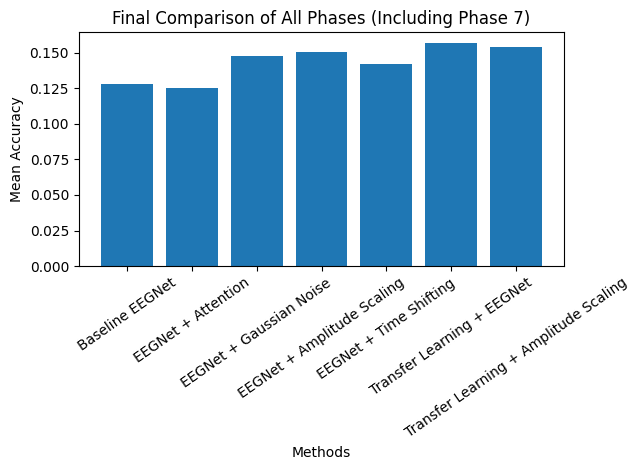

In [45]:
# STEP 2 — Final comparison plot (ALL 7 PHASES)


plt.figure()

plt.bar(results_summary["Method"], results_summary["Mean Accuracy"])

plt.xticks(rotation=35)

plt.xlabel("Methods")
plt.ylabel("Mean Accuracy")
plt.title("Final Comparison of All Phases (Including Phase 7)")

plt.tight_layout()
plt.show()



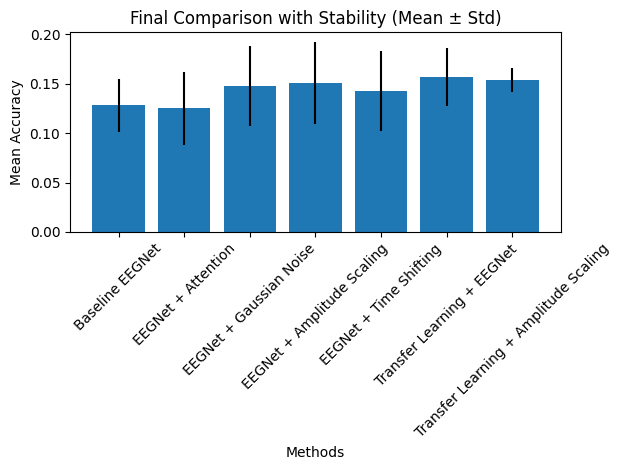

In [46]:
# STEP 3 — Error bar plot (VERY IMPORTANT)

plt.figure()

plt.bar(
    results_summary["Method"],
    results_summary["Mean Accuracy"],
    yerr=results_summary["Std Dev"]
)

plt.xticks(rotation=45)

plt.xlabel("Methods")
plt.ylabel("Mean Accuracy")
plt.title("Final Comparison with Stability (Mean ± Std)")

plt.tight_layout()
plt.show()
